In [156]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
print("All modules import Sucessfully")

All modules import Sucessfully


In [157]:
df = pd.read_csv(r"C:\Users\AlokVerma\Desktop\ML DATA\50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [158]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [159]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [160]:
df.head(2)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.2,136897.80,471784.10,New York,192261.83
1,162597.7,151377.59,443898.53,California,191792.06


In [161]:
X = df.iloc[:,0:4].values
y = df.iloc[:,-1].values

In [184]:
# dummy_encoder
# ordinal Encoding
# one hot encoding
# Column Transformation

In [185]:
from sklearn.preprocessing import OneHotEncoder

In [186]:
from sklearn.compose import ColumnTransformer

In [187]:
ct = ColumnTransformer(
    transformers=[
       ("tf1", OneHotEncoder(drop="first", sparse_output=False), [3])
    ],
    remainder="passthrough"
                      )

In [188]:
X = np.array(ct.fit_transform(X))

In [189]:
X

array([[ 0.        ,  0.        ,  0.        , ...,  1.39326109,
         2.01641149,  2.15394309],
       [ 0.        ,  0.        ,  0.        , ..., -0.71774056,
         1.95586034,  1.9236004 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.71774056,
         1.75436374,  1.62652767],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.71774056,
        -1.62236202, -1.74312698],
       [ 1.        ,  0.        ,  0.        , ...,  1.39326109,
        -1.61043334, -1.74312698],
       [ 0.        ,  0.        ,  0.        , ..., -0.71774056,
        -1.62236202, -1.36998473]])

In [190]:
from sklearn.preprocessing import StandardScaler

In [191]:
sc = StandardScaler()

In [192]:
X = sc.fit_transform(X)

In [193]:
X

array([[-0.14285714, -0.14285714, -0.14285714, ...,  1.39326109,
         2.01641149,  2.15394309],
       [-0.14285714, -0.14285714, -0.14285714, ..., -0.71774056,
         1.95586034,  1.9236004 ],
       [-0.14285714, -0.14285714, -0.14285714, ..., -0.71774056,
         1.75436374,  1.62652767],
       ...,
       [-0.14285714, -0.14285714, -0.14285714, ..., -0.71774056,
        -1.62236202, -1.74312698],
       [ 7.        , -0.14285714, -0.14285714, ...,  1.39326109,
        -1.61043334, -1.74312698],
       [-0.14285714, -0.14285714, -0.14285714, ..., -0.71774056,
        -1.62236202, -1.36998473]])

In [194]:
from sklearn.model_selection import train_test_split

In [203]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [204]:
from sklearn.linear_model import LinearRegression

In [208]:

len(y_train)

40

In [209]:
model = LinearRegression()

In [210]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [212]:
y_pred = model.predict(X_test)

In [213]:
y_pred

array([124735.39137254, 117550.8119265 , 107346.88081391, 155838.98734724,
       122368.22214223,  81383.1780668 ,  94853.52993469, 108603.88883135,
       100051.60411959, 108399.73564559])

In [214]:
import matplotlib.pyplot as plt

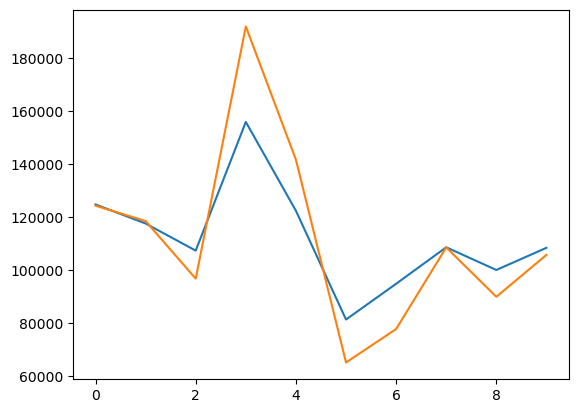

In [222]:
plt.plot(y_pred)
plt.plot(y_test)

In [229]:
accuracy = model.score(X_test, y_test)
print("Accuracy:", round(accuracy*100,2))

Accuracy: 78.93
